## Q3


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import arviz as az
from sympy import symbols, diff, solve

beta0, beta1, beta2, beta3, beta4, beta5, beta6, beta7, beta8, beta9 = symbols(
    "beta0 beta1 beta2 beta3 beta4 beta5 beta6 beta7 beta8 beta9", real=True
)
x1, x2, x3, x4, x5, x6, x7, x8 = symbols("x1 x2 x3 x4 x5 x6 x7 x8", real=True)

f = (
    beta0
    + beta1 * x1
    + beta2 * x2
    + beta3 * x3
    + beta4 * x4
    + beta5 * x5
    + beta6 * x6
    + beta7 * x7
    + beta8 * x8
    + beta9 * x8**2
)

der = diff(f, x8)
der

/Users/aaron/miniforge3/envs/pymc_spr26/lib/python3.14/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,


beta8 + 2*beta9*x8

In [21]:
solve(der, x8)

[-beta8/(2*beta9)]

In [3]:
concrete = pd.read_csv("concrete.csv", sep="\t")
concrete

,x1,x2,x3,x4,x5,x6,x7,x8,y
0,5.40,0.00,0.00,1.62,0.25,10.40,6.76,28,134.43
1,5.40,0.00,0.00,1.62,0.25,10.55,6.76,28,61.89
2,3.33,1.43,0.00,2.28,0.00,9.32,5.94,270,40.27
3,3.33,1.43,0.00,2.28,0.00,9.32,5.94,365,41.05
4,1.99,1.32,0.00,1.92,0.00,9.78,8.26,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,2.76,1.16,0.90,1.80,0.89,8.70,7.68,28,44.28
1026,3.22,0.00,1.16,1.96,1.04,8.18,8.13,28,31.18
1027,1.49,1.39,1.09,1.93,0.61,8.92,7.80,28,23.70
1028,1.59,1.87,0.00,1.76,1.13,9.90,7.89,28,32.77


In [4]:
X = concrete.iloc[:, :8]
X["x9"] = X["x8"] ** 2

X_array = X.to_numpy()
y = concrete.iloc[:, 8].to_numpy()

In [5]:
with pm.Model() as concrete_model:
    X_data = pm.Data("X", X_array)
    y_data = pm.Data("y", y)

    alpha = pm.Normal("alpha", 0, 100)
    beta = pm.Normal("beta", 0, 100, shape=X.shape[1])
    sigma = pm.Exponential("sigma", 0.01)

    mu = alpha + pm.math.dot(X_data, beta)

    # take derivative of mu and set equal to 0, solve for age (x8 and x9)
    # this is the answer to part 4
    age = pm.Deterministic("age", -beta[7] / (2 * beta[8]))

    pm.Normal("likelihood", mu, sigma, observed=y_data, shape=X_data.shape[0])
    trace = pm.sample(2000, idata_kwargs=dict(log_likelihood=True))
    pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 19 seconds.
Sampling: [likelihood]


Output()

In [7]:
az.summary(trace, hdi_prob=0.90)

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,36.244,18.062,8.307,67.646,0.391,0.256,2144.0,3030.0,1.0
beta[0],10.122,0.677,9.022,11.259,0.014,0.009,2444.0,3758.0,1.0
beta[1],8.543,0.815,7.207,9.891,0.016,0.010,2585.0,3984.0,1.0
beta[2],5.587,1.089,3.785,7.342,0.021,0.013,2730.0,4035.0,1.0
beta[3],-21.137,3.242,-26.518,-15.832,0.060,0.039,2912.0,3863.0,1.0
beta[4],1.630,1.006,-0.104,3.174,0.015,0.011,4513.0,5400.0,1.0
beta[5],-0.737,0.662,-1.879,0.317,0.013,0.008,2799.0,3876.0,1.0
beta[6],-0.544,0.786,-1.889,0.704,0.016,0.009,2480.0,3684.0,1.0
beta[7],0.350,0.015,0.324,0.374,0.000,0.000,3962.0,4505.0,1.0
beta[8],-0.001,0.000,-0.001,-0.001,0.000,0.000,4050.0,4517.0,1.0


In [9]:
new_X = np.array([2.5, 1, 0.5, 1.8, 0.6, 8, 7, 30, 30**2])[np.newaxis, :]

with concrete_model:
    pm.set_data({"X": new_X})
    ppc = pm.sample_posterior_predictive(trace, predictions=True)

az.summary(ppc.predictions, hdi_prob=0.90, kind="stats")

Sampling: [likelihood]


Output()

,mean,sd,hdi_5%,hdi_95%
likelihood[0],35.77,11.634,16.987,54.846


In [14]:
loo = az.loo(trace, scale="deviance", pointwise=True)
loo

/Users/aaron/miniforge3/envs/pymc_spr26/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 1030 observations log-likelihood matrix.

             Estimate       SE
deviance_loo  7978.56   184.32
p_loo           29.23        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1027   99.7%
   (0.70, 1]   (bad)         3    0.3%
   (1, Inf)   (very bad)    0    0.0%

In [9]:
X.shape

(1030, 9)

In [13]:
high_k_idx = np.where(loo.pareto_k.values > 0.7)
print(high_k_idx)
concrete.iloc[high_k_idx]

(array([595, 675, 717]),)


,x1,x2,x3,x4,x5,x6,x7,x8,y
595,1.86,1.24,0.0,1.86,0.3,1.83,2.64,28,17.60
675,1.84,1.23,0.0,2.04,0.9,5.90,8.00,90,124.53
717,1.41,2.12,0.0,2.04,0.0,9.72,7.49,3,134.83


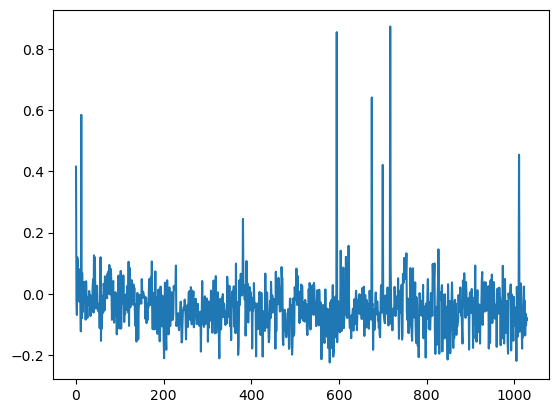

In [11]:
plt.plot(loo.pareto_k)

In [12]:
def evaluate_ecdf(trace: az.InferenceData) -> np.array:
    """Evaluates ECDF at original observed values.

    This function assumes a single set of observed values.

    Args:
        trace: arviz.InferenceData from running a PyMC model.

    Returns:
        A Numpy array of the ECDF evaluation at each original datapoint.
    """
    # get posterior predictive variable name
    ppc_vars = list(trace.posterior_predictive.data_vars)
    assert (
        len(ppc_vars) == 1
    ), "Number of variables in posterior predictive must equal 1."
    y_varname = ppc_vars[0]

    # get original observations
    y_obs = trace.observed_data[y_varname].values
    assert (
        len(y_obs.shape) == 1
    ), "Y-observations shape must be one-dimensional."
    n_obs = y_obs.shape[0]
    y_obs = y_obs.reshape(-1, 1)  # for broadcasting

    # get posterior predictive samples for each y_obs and sample count
    y_samples_per_obs = trace.posterior_predictive[y_varname].stack(
        sample=("chain", "draw")
    )
    assert y_samples_per_obs.shape[0] == n_obs, "Shape assumptions aren't met."
    n_samples = y_samples_per_obs.shape[1]

    # evaluate ECDF at each y_obs and convert to numpy array
    ecdf_values = y_samples_per_obs <= y_obs
    prob = ecdf_values.sum(dim="sample") / n_samples

    return prob.to_numpy()

In [13]:
ecdf_output = evaluate_ecdf(trace)
ecdf_mask = np.logical_or(ecdf_output > 0.99, ecdf_output < 0.01)
np.nonzero(ecdf_mask), ecdf_output[ecdf_mask]

((array([   0,   12,  381,  383,  639,  675,  700,  717,  735, 1011]),),
 array([1.      , 1.      , 1.      , 0.996125, 0.      , 1.      ,
        1.      , 1.      , 0.      , 1.      ]))

In [14]:
loo_pit_output = az.loo_pit(trace, y="likelihood")
loo_pit_mask = np.logical_or(loo_pit_output > 0.99, loo_pit_output < 0.01)
np.nonzero(loo_pit_mask), loo_pit_output[loo_pit_mask]

((array([   0,   12,  381,  383,  639,  675,  700,  717,  735, 1011]),),
 array([1.        , 1.        , 1.        , 0.99672859, 0.        ,
        1.        , 1.        , 1.        , 0.        , 1.        ]))

In [15]:
X_no6 = X.drop(["x6"], axis=1).to_numpy()
X_no7 = X.drop(["x7"], axis=1).to_numpy()

In [16]:
with pm.Model() as concrete_model_all:
    X_data = pm.Data("X", X_array)
    y_data = pm.Data("y", y)

    alpha = pm.Normal("alpha", 0, 100)
    beta = pm.Normal("beta", 0, 100, shape=X.shape[1])
    sigma = pm.Exponential("sigma", 0.05)

    mu = alpha + pm.math.dot(X_data, beta)

    pm.Normal("likelihood", mu, sigma, observed=y_data)

    cctrace_all = pm.sample(5000)
    pm.compute_log_likelihood(cctrace_all)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 38 seconds.


Output()

In [17]:
with pm.Model() as concrete_model_no6:
    X_data = pm.Data("X", X_no6)
    y_data = pm.Data("y", y)

    alpha = pm.Normal("alpha", 0, 100)
    beta = pm.Normal("beta", 0, 100, shape=X_no6.shape[1])
    sigma = pm.Exponential("sigma", 0.05)

    mu = alpha + pm.math.dot(X_data, beta)

    pm.Normal("likelihood", mu, sigma, observed=y_data)

    cctrace_no6 = pm.sample(5000)
    pm.compute_log_likelihood(cctrace_no6)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 20 seconds.


Output()

In [18]:
with pm.Model() as concrete_model_no7:
    X_data = pm.Data("X", X_no7)
    y_data = pm.Data("y", y)

    alpha = pm.Normal("alpha", 0, 100)
    beta = pm.Normal("beta", 0, 100, shape=X_no7.shape[1])
    sigma = pm.Exponential("sigma", 0.05)

    mu = alpha + pm.math.dot(X_data, beta)
    pm.Normal("likelihood", mu, sigma, observed=y_data)

    cctrace_no7 = pm.sample(5000)
    pm.compute_log_likelihood(cctrace_no7)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

/Users/aaron/miniforge3/envs/pymc_f25_2/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 20 seconds.


Output()

In [ ]:
models = {
    "Full model": cctrace_all,
    "Without X_6": cctrace_no6,
    "Without X_7": cctrace_no7,
}
az.compare(models)

/Users/aaron/miniforge3/envs/pymc_f25_2/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/aaron/miniforge3/envs/pymc_f25_2/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/aaron/miniforge3/envs/pymc_f25_2/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Without X_6,0,-3986.989930,25.232409,0.000000,0.903609,92.497928,0.000000,True,log
Without X_7,1,-3987.304348,26.619768,0.314418,0.096391,92.544664,0.883945,True,log
Full model,2,-3989.083018,28.780772,2.093088,0.000000,92.440976,1.971937,True,log
